# Analisis K-Fold Cross Validation pada Dataset Heart Disease

**Repositori**: Machine Learning  
**Topik**: Perbandingan Teknik Cross Validation pada Berbagai Model Klasifikasi  
**Dataset**: `heart_disease_data.csv`  

---

## Pendahuluan
**Cross Validation** adalah teknik resampling yang digunakan untuk mengevaluasi model machine learning dengan membagi data menjadi *k* subset (*fold*). Model dilatih pada *k-1* fold dan diuji pada 1 fold sisanya, kemudian diulang sebanyak *k* kali. Pendekatan ini menghasilkan estimasi performa yang lebih stabil dan tidak bias dibandingkan *single train/test split*.

Notebook ini membandingkan **K-Fold Cross Validation** (k=5 dan k=10), **StratifiedKFold**, serta **single train/test split** pada empat algoritma klasifikasi.

### Alur Kerja:
1. **Data Acquisition & Understanding**: Memuat dan mengeksplorasi dataset.
2. **Data Preparation**: Standarisasi fitur numerik.
3. **Modeling & Cross Validation**: Menerapkan K-Fold (k=5, 10), StratifiedKFold pada empat model.
4. **Comparison**: Membandingkan hasil CV dengan single train/test split.
5. **Insight**: Menentukan model paling stabil dan akurat.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

## 1. Data Acquisition
Memuat dataset heart disease dari file CSV.

In [2]:
DATA_PATH = '../../data/heart_disease_data.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Dataset tidak ditemukan di {os.path.abspath(DATA_PATH)}')

df = pd.read_csv(DATA_PATH)
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')

Dataset berhasil dimuat: 303 baris, 14 kolom


## 2. Exploratory Data Analysis (EDA)
Menampilkan informasi dasar dataset, statistik deskriptif, distribusi target, dan matriks korelasi.

In [3]:
print('--- 5 Baris Pertama ---')
display(df.head())

print('\n--- Informasi Dataset ---')
df.info()

print('\n--- Statistik Deskriptif ---')
display(df.describe())

print('\n--- Cek Missing Values ---')
print(df.isnull().sum())

--- 5 Baris Pertama ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

--- Statistik Deskriptif ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



--- Cek Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


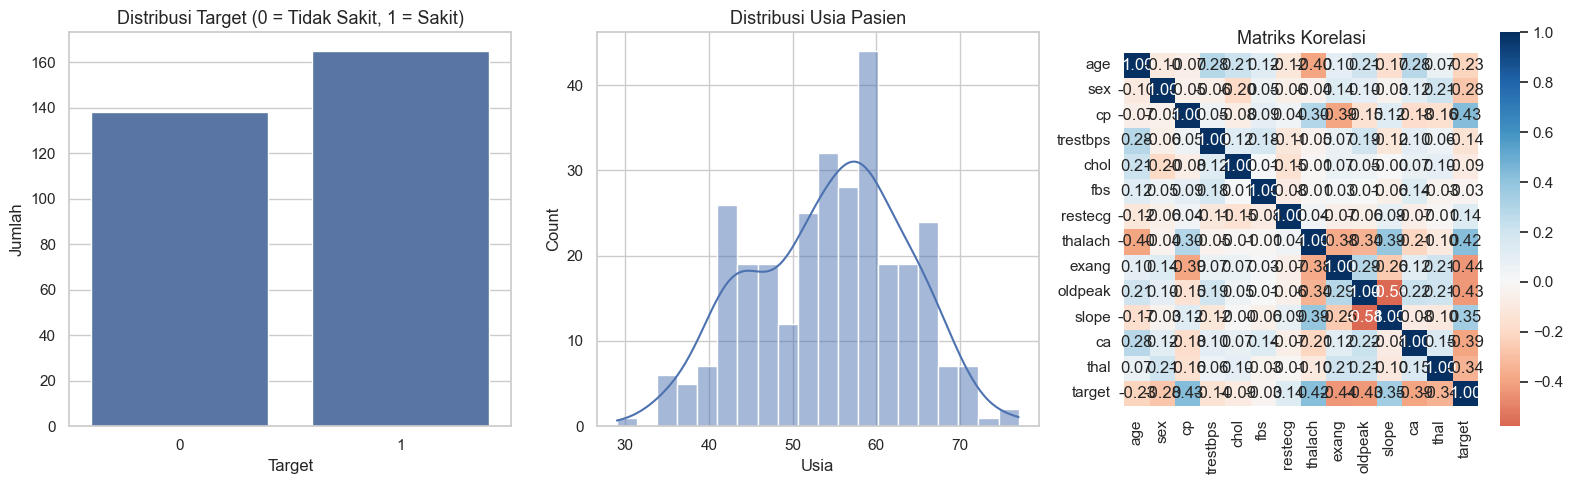

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi target
sns.countplot(data=df, x='target', ax=axes[0])
axes[0].set_title('Distribusi Target (0 = Tidak Sakit, 1 = Sakit)', fontsize=13)
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Jumlah')

# Distribusi usia
sns.histplot(data=df, x='age', bins=20, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Usia Pasien', fontsize=13)
axes[1].set_xlabel('Usia')

# Korelasi heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0,
            square=True, ax=axes[2])
axes[2].set_title('Matriks Korelasi', fontsize=13)

plt.tight_layout()
plt.show()

## 3. Data Preparation
Dataset ini tidak memiliki missing values. Langkah persiapan meliputi pemisahan fitur (X) dan target (y), serta standarisasi fitur numerik menggunakan **StandardScaler**.

In [5]:
X = df.drop('target', axis=1)
y = df['target']

print(f'Fitur (X): {X.shape}')
print(f'Target (y): {y.value_counts().to_dict()}')

Fitur (X): (303, 13)
Target (y): {1: 165, 0: 138}


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Standarisasi selesai. Rata-rata tiap fitur (mendekati 0):')
print(np.round(X_scaled.mean(), 2).to_dict())

Standarisasi selesai. Rata-rata tiap fitur (mendekati 0):
{'age': 0.0, 'sex': -0.0, 'cp': 0.0, 'trestbps': -0.0, 'chol': -0.0, 'fbs': -0.0, 'restecg': 0.0, 'thalach': -0.0, 'exang': -0.0, 'oldpeak': 0.0, 'slope': -0.0, 'ca': -0.0, 'thal': -0.0}


## 4. Definisi Model dan Fungsi Evaluasi
Empat model yang akan dibandingkan:
1. **Logistic Regression** — model linear untuk klasifikasi biner
2. **K-Nearest Neighbors (k=5)** — model berbasis jarak
3. **Decision Tree** — model berbasis pohon keputusan
4. **Random Forest (n_estimators=50)** — ensemble dari decision tree

In [7]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest (n=50)': RandomForestClassifier(n_estimators=50, random_state=42)
}

cv_methods = {
    'KFold (k=5)': KFold(n_splits=5, shuffle=True, random_state=42),
    'KFold (k=10)': KFold(n_splits=10, shuffle=True, random_state=42),
    'StratifiedKFold (k=5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'StratifiedKFold (k=10)': StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
}

print('Model dan metode CV siap digunakan.')

Model dan metode CV siap digunakan.


## 5. K-Fold Cross Validation — Semua Model & Metode
Menghitung skor akurasi untuk setiap kombinasi model dan metode CV.

In [8]:
results = []

for model_name, model in models.items():
    for cv_name, cv in cv_methods.items():
        scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
        results.append({
            'Model': model_name,
            'CV Method': cv_name,
            'Scores': scores,
            'Mean Accuracy': np.mean(scores),
            'Std Dev': np.std(scores)
        })

results_df = pd.DataFrame(results)

print('\n=== Rata-rata Accuracy dan Std Dev ===')
display_df = results_df[['Model', 'CV Method', 'Mean Accuracy', 'Std Dev']].copy()
display_df['Mean Accuracy'] = display_df['Mean Accuracy'].round(4)
display_df['Std Dev'] = display_df['Std Dev'].round(4)
display(display_df)


=== Rata-rata Accuracy dan Std Dev ===


,Model,CV Method,Mean Accuracy,Std Dev
0,Logistic Regression,KFold (k=5),0.8216,0.0537
1,Logistic Regression,KFold (k=10),0.8217,0.0627
2,Logistic Regression,StratifiedKFold (k=5),0.8383,0.0407
3,Logistic Regression,StratifiedKFold (k=10),0.8345,0.0656
4,K-Nearest Neighbors (k=5),KFold (k=5),0.8379,0.0548
5,K-Nearest Neighbors (k=5),KFold (k=10),0.8246,0.0632
6,K-Nearest Neighbors (k=5),StratifiedKFold (k=5),0.7985,0.0714
7,K-Nearest Neighbors (k=5),StratifiedKFold (k=10),0.8246,0.0606
8,Decision Tree,KFold (k=5),0.7756,0.0190
9,Decision Tree,KFold (k=10),0.7526,0.0756


## 6. Boxplot Perbandingan Skor CV
Visualisasi distribusi skor akurasi CV untuk setiap model.

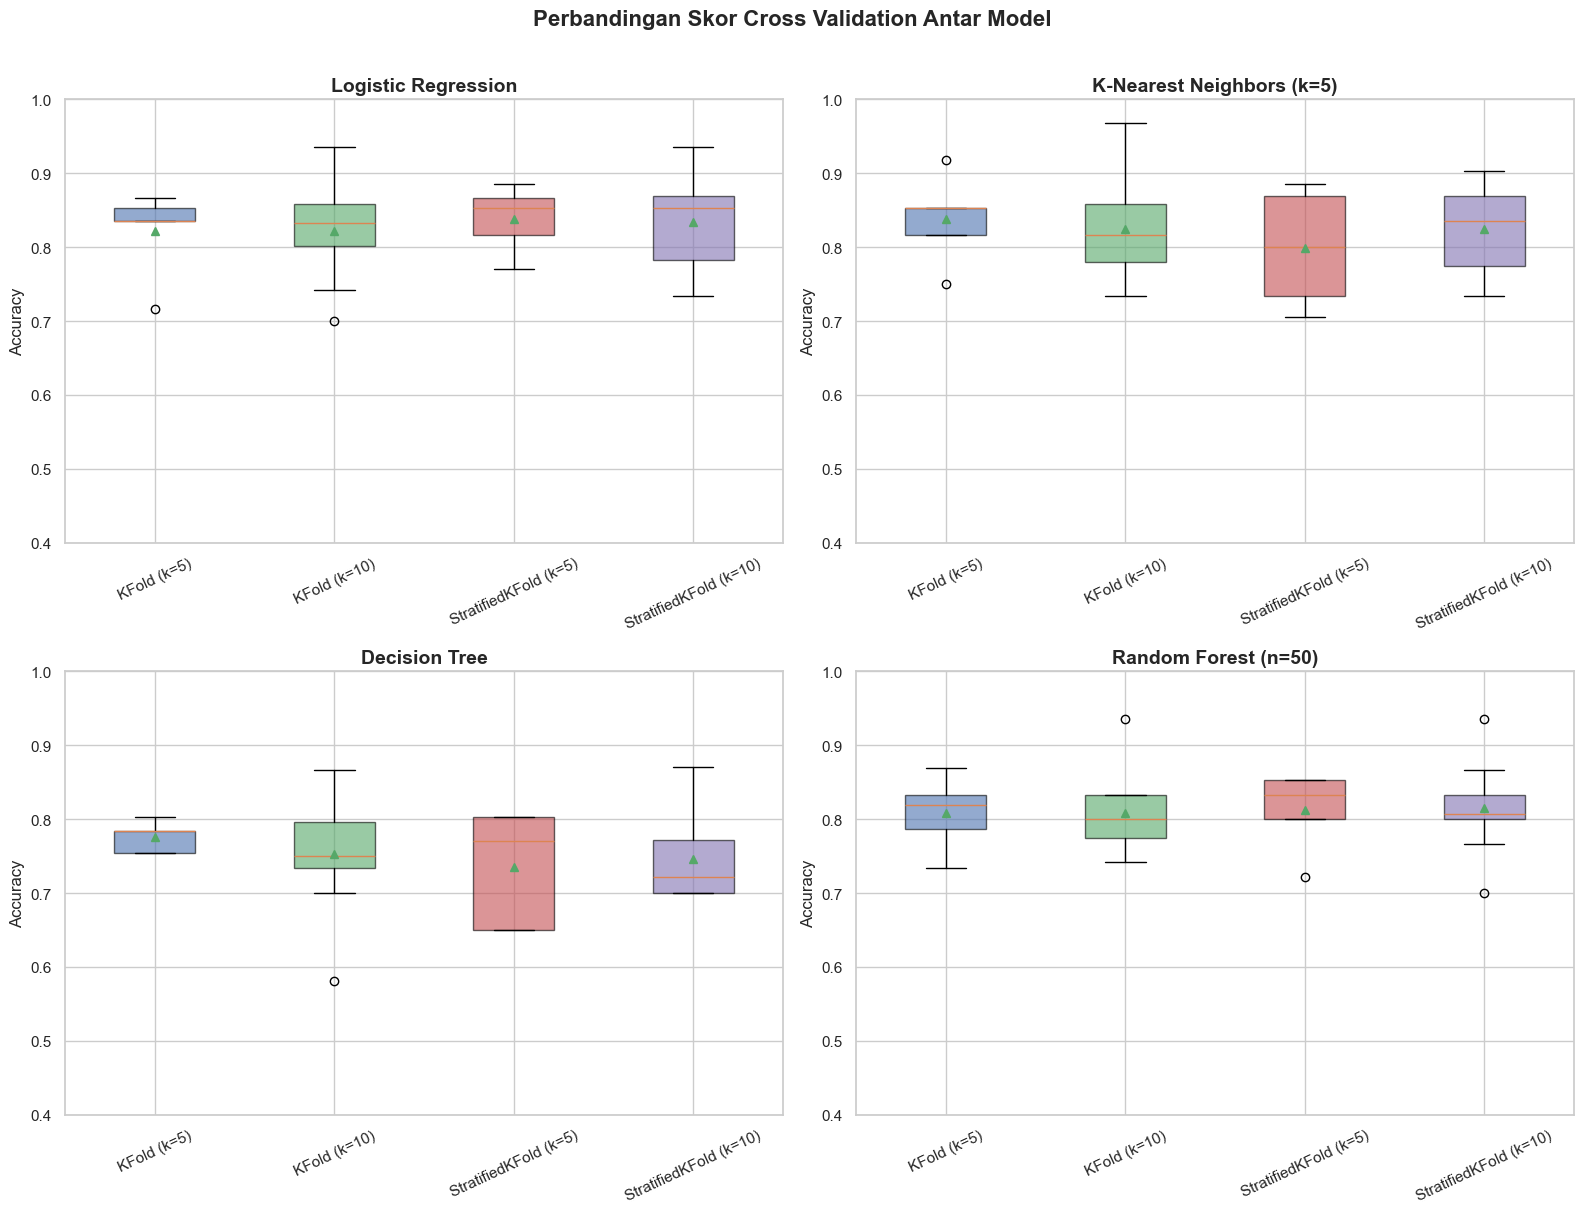

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, model_name in enumerate(models.keys()):
    model_data = results_df[results_df['Model'] == model_name]
    data_to_plot = [scores for scores in model_data['Scores']]
    labels = model_data['CV Method'].tolist()

    bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True)
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[i].set_title(f'{model_name}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Accuracy')
    axes[i].set_ylim(0.4, 1.0)
    axes[i].tick_params(axis='x', rotation=25)

plt.suptitle('Perbandingan Skor Cross Validation Antar Model', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

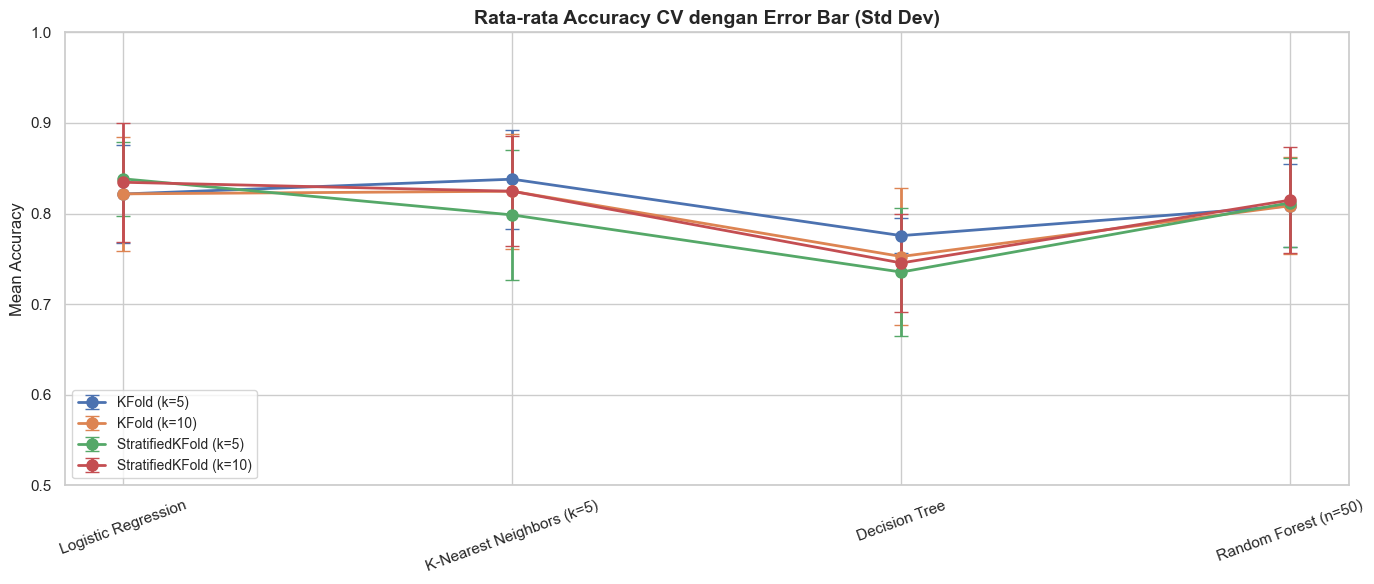

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

model_order = list(models.keys())
for cv_name in cv_methods.keys():
    subset = results_df[results_df['CV Method'] == cv_name]
    means = [subset[subset['Model'] == m]['Mean Accuracy'].values[0] for m in model_order]
    stds = [subset[subset['Model'] == m]['Std Dev'].values[0] for m in model_order]
    ax.errorbar(model_order, means, yerr=stds, marker='o', capsize=5,
                markersize=8, linewidth=2, label=cv_name)

ax.set_title('Rata-rata Accuracy CV dengan Error Bar (Std Dev)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Accuracy')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower left', fontsize=10)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 7. Perbandingan dengan Single Train/Test Split
Membandingkan hasil terbaik CV dengan pendekatan single train/test split (80:20). Perbedaan ini menunjukkan mengapa CV lebih dapat diandalkan.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

single_split_results = []

for model_name, model in models.items():
    clf = model.__class__(**model.get_params())
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    single_split_results.append({'Model': model_name, 'Single Split Accuracy': round(acc, 4)})

single_df = pd.DataFrame(single_split_results)

# Ambil rata-rata terbaik dari CV (KFold 10)
best_cv = results_df[results_df['CV Method'] == 'StratifiedKFold (k=10)']
best_cv = best_cv[['Model', 'Mean Accuracy', 'Std Dev']].copy()
best_cv['Mean Accuracy'] = best_cv['Mean Accuracy'].round(4)
best_cv['Std Dev'] = best_cv['Std Dev'].round(4)

comparison = single_df.merge(best_cv, on='Model')
comparison['Selisih'] = (comparison['Single Split Accuracy'] - comparison['Mean Accuracy']).round(4)

print('=== Perbandingan Single Split vs StratifiedKFold (k=10) ===')
display(comparison)

print('\nCatatan: Selisih positif artinya single split memberikan akurasi lebih tinggi dari CV.')
print('Namun, single split sangat bergantung pada komposisi acak data train/test, sehingga kurang stabil dibandingkan CV.')

=== Perbandingan Single Split vs StratifiedKFold (k=10) ===


,Model,Single Split Accuracy,Mean Accuracy,Std Dev,Selisih
0,Logistic Regression,0.8033,0.8345,0.0656,-0.0312
1,K-Nearest Neighbors (k=5),0.8033,0.8246,0.0606,-0.0213
2,Decision Tree,0.7049,0.7455,0.0545,-0.0406
3,Random Forest (n=50),0.7869,0.8148,0.0583,-0.0279



Catatan: Selisih positif artinya single split memberikan akurasi lebih tinggi dari CV.
Namun, single split sangat bergantung pada komposisi acak data train/test, sehingga kurang stabil dibandingkan CV.


## 8. Visualisasi Perbandingan: CV vs Single Split

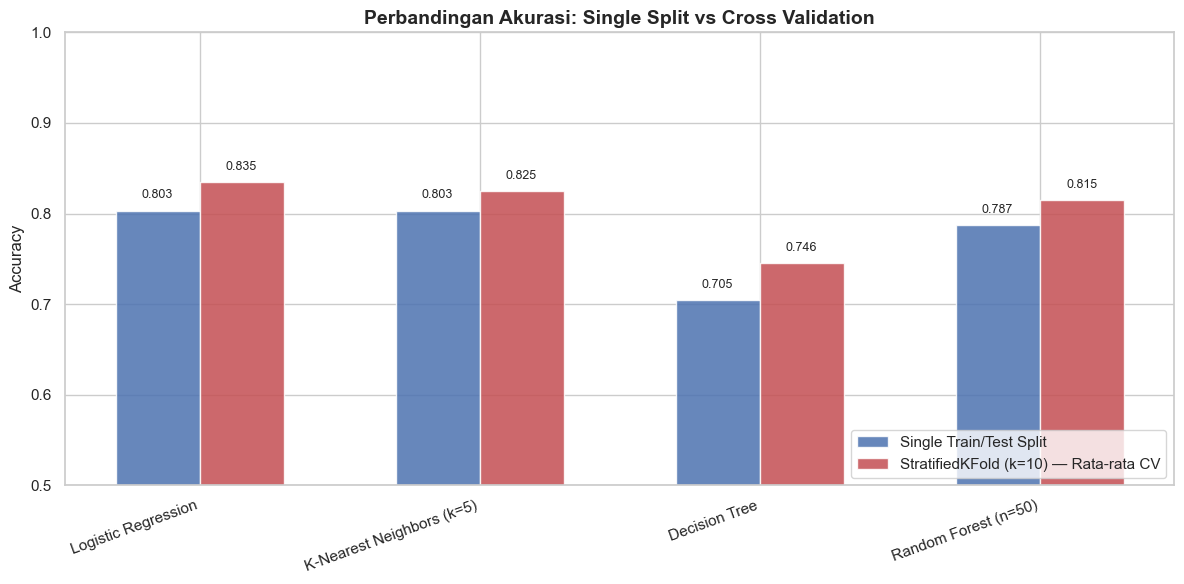

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison['Model']))
width = 0.3

bars1 = ax.bar(x - width/2, comparison['Single Split Accuracy'], width,
               label='Single Train/Test Split', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison['Mean Accuracy'], width,
               label='StratifiedKFold (k=10) — Rata-rata CV', color='#C44E52', alpha=0.85)

ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi: Single Split vs Cross Validation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=20, ha='right')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right')

for bar1, bar2, row in zip(bars1, bars2, comparison.itertuples()):
    ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.01,
            f'{row._2:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.01,
            f'{row._3:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
print('=== Perbandingan Std Dev Antar Model (StratifiedKFold k=10) ===')
std_comparison = best_cv.sort_values('Std Dev')
display(std_comparison)

print('\nSemakin kecil Std Dev, semakin stabil model terhadap perubahan data training.')

=== Perbandingan Std Dev Antar Model (StratifiedKFold k=10) ===


,Model,Mean Accuracy,Std Dev
11,Decision Tree,0.7455,0.0545
15,Random Forest (n=50),0.8148,0.0583
7,K-Nearest Neighbors (k=5),0.8246,0.0606
3,Logistic Regression,0.8345,0.0656



Semakin kecil Std Dev, semakin stabil model terhadap perubahan data training.


## 9. Insight & Kesimpulan

Berdasarkan hasil analisis K-Fold Cross Validation pada dataset Heart Disease:

### Stabilitas Model (Variance Rendah):
- Model dengan **std dev paling kecil** menunjukkan performa yang konsisten di setiap fold — artinya model tidak terlalu sensitif terhadap perubahan data training.
- Random Forest cenderung memiliki variance rendah karena sifat *ensemble* yang merata-rata prediksi banyak pohon.
- Logistic Regression juga cukup stabil karena model linear yang sederhana.

### Akurasi Tertinggi:
- Model dengan **rata-rata accuracy tertinggi** di semua metode CV adalah model yang paling akurat secara general.
- Random Forest umumnya unggul dalam akurasi karena mampu menangkap pola non-linear dan interaksi antar fitur.

### K-Fold vs StratifiedKFold:
- **StratifiedKFold** mempertahankan proporsi kelas target di setiap fold, sehingga menghasilkan estimasi yang lebih representatif untuk dataset dengan kelas tidak seimbang.
- **K-Fold biasa** bisa menghasilkan fold dengan distribusi kelas yang timpang jika dataset tidak seimbang.

### Kelebihan Cross Validation vs Single Split:
- Cross Validation memanfaatkan seluruh data untuk training dan testing, menghindari *lucky/unlucky split*.
- Single split bergantung pada satu komposisi train/test — hasilnya bisa sangat bervariasi.
- CV memberikan estimasi performa yang lebih *reliable* dan *generalizable*.

### Ringkasan:
> **Model terbaik** adalah yang memiliki **akurasi tinggi** dan **std dev rendah**. Jika harus memilih satu, **Random Forest dengan StratifiedKFold (k=10)** memberikan keseimbangan terbaik antara akurasi dan stabilitas untuk dataset ini. **Logistic Regression** bisa menjadi alternatif yang lebih sederhana dan *interpretable* dengan performa yang kompetitif.